# 1. Import

In [1]:
import os
import numpy as np
import pydicom
import cv2
from pathlib import Path
from typing import List, Tuple, Dict, Optional
from scipy import ndimage
import warnings
import gc
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

warnings.filterwarnings('ignore')

In [2]:
import sys
import gc
import json
import shutil
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from typing import List, Dict, Optional, Tuple
from matplotlib import pyplot as plt
from glob import glob

# Data handling
import numpy as np
import polars as pl
import pandas as pd

# Medical imaging
import pydicom
import cv2

# ML/DL
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast
import timm

# Transformations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Competition API
# import kaggle_evaluation.rsna_inference_server


# 2. Configuration

In [3]:


# DICOM preprocessor (DICOMPreprocessorKaggle class defined in previous cell)
# In actual use, define in the same file or import appropriately

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f"Using device: {device}")

# ====================================================
# Competition constants
# ====================================================
ID_COL = 'SeriesInstanceUID'
LABEL_COLS = [
    'Left Infraclinoid Internal Carotid Artery',
    'Right Infraclinoid Internal Carotid Artery',
    'Left Supraclinoid Internal Carotid Artery',
    'Right Supraclinoid Internal Carotid Artery',
    'Left Middle Cerebral Artery',
    'Right Middle Cerebral Artery',
    'Anterior Communicating Artery',
    'Left Anterior Cerebral Artery',
    'Right Anterior Cerebral Artery',
    'Left Posterior Communicating Artery',
    'Right Posterior Communicating Artery',
    'Basilar Tip',
    'Other Posterior Circulation',
    'Aneurysm Present',
]

# ====================================================
# Configuration
# ====================================================
class InferenceConfig:
    # Model settings
    model_name = "tf_efficientnetv2_s.in21k_ft_in1k"
    size = 512 # default: 384
    target_cols = LABEL_COLS
    num_classes = len(target_cols)
    in_chans = 32
    
    # Preprocessing settings
    target_shape = (in_chans, 512, 512)  # (depth, height, width) default: (32, 384, 384)
    continued = False

CFG = InferenceConfig()

# 3. Preprocessor

In [4]:
class DICOMPreprocessorKaggle:
    """
    DICOM preprocessing system for Kaggle Code Competition
    Converts original DICOMPreprocessor logic to single series processing
    
    以下、主要なメソッドの説明：
    load_dicom_series
	― ds = pydicom.dcmread(filepath, force=True)をdatasets.append(ds)
	― datasetsはSeriesごとのメタデータや画像の集まり。

    _process_single_3d_dicom
        ― len(datasets)==1のときに実行される。
        ― おそらく既存のpreprocessとほとんど同じ処理。
        ― ただ、resize_volume_3dはちょっと違うかも？

    resize_volume_3d
        ― ndimage.zoom(volume, [channel, height, width], ...)でそれぞれの次元を拡大。

    _process_multiple_2d_dicoms
        ― 

    extract_slice_info
        ― datasetsから、dataset、index、instance_number、z_positionというメタデータを取得し、slice_info: Listとしてreturn。

    sort_slices_by_position
        ― z_positionをもとに、slice_infoを並び替え
    """
    
    def __init__(self, target_shape: Tuple[int, int, int] = CFG.target_shape):
        self.target_depth, self.target_height, self.target_width = target_shape
        
    def load_dicom_series(self, series_path: str) -> Tuple[List[pydicom.Dataset], str, Dict]:
        """
        Load DICOM series
        """
        series_path = Path(series_path)
        series_name = series_path.name
        
        # Search for DICOM files
        dicom_files = []
        for root, _, files in os.walk(series_path):
            for file in files:
                if file.endswith('.dcm'):
                    dicom_files.append(os.path.join(root, file))
        
        if not dicom_files:
            raise ValueError(f"No DICOM files found in {series_path}")
        
        #print(f"Found {len(dicom_files)} DICOM files in series {series_name}")
        
        # Load DICOM datasets
        datasets = []
        metadata = dict()
        for i, filepath in enumerate(dicom_files):
            try:
                ds = pydicom.dcmread(filepath, force=True)
                datasets.append(ds)
                
                # 1つ目のDICOMからメタデータを取得
                if i == 0:
                    metadata['modality'] = getattr(ds, 'Modality', 'CT')
                    # 'PatientAge'属性を取得（デフォルト値は'050Y'）
                    try:
                        age_str = getattr(ds, 'PatientAge', '050Y')
                        age = int(''.join(filter(str.isdigit, age_str[:3])) or '50')
                        metadata['age'] = min(age, 100)
                    except:
                        metadata['age'] = 50

                    # 'PatientSex'属性を取得（デフォルト値は'M'）
                    try:
                        sex = getattr(ds, 'PatientSex', 'M')
                        metadata['sex'] = 1 if sex == 'M' else 0
                    except:
                        metadata['sex'] = 0
            except Exception as e:
                #print(f"Failed to load {filepath}: {e}")
                continue
        
        if not datasets:
            raise ValueError(f"No valid DICOM files in {series_path}")
        
        return datasets, series_name, metadata
    
    def extract_slice_info(self, datasets: List[pydicom.Dataset]) -> List[Dict]:
        """
        Extract position information for each slice
        """
        slice_info = []
        
        
        for i, ds in enumerate(datasets):
            info = {
                'dataset': ds,
                'index': i,
                'instance_number': getattr(ds, 'InstanceNumber', i),
            }
            
            # Get z-coordinate from ImagePositionPatient
            try:
                position = getattr(ds, 'ImagePositionPatient', None)
                if position is not None and len(position) >= 3:
                    info['z_position'] = float(position[2])
                else:
                    # Fallback: use InstanceNumber
                    info['z_position'] = float(info['instance_number'])
                    #print("ImagePositionPatient not found, using InstanceNumber")
            except Exception as e:
                info['z_position'] = float(i)
                #print(f"Failed to extract position info: {e}")
            
            slice_info.append(info)
        
        return slice_info
    
    def sort_slices_by_position(self, slice_info: List[Dict]) -> List[Dict]:
        """
        Sort slices by z-coordinate
        """
        # Sort by z-coordinate
        sorted_slices = sorted(slice_info, key=lambda x: x['z_position'])
        
        #print(f"Sorted {len(sorted_slices)} slices by z-position")
        #print(f"Z-range: {sorted_slices[0]['z_position']:.2f} to {sorted_slices[-1]['z_position']:.2f}")
        
        return sorted_slices
    
    def get_windowing_params(self, ds: pydicom.Dataset, img: np.ndarray = None) -> Tuple[Optional[float], Optional[float]]:
        """
        Get windowing parameters based on modality
        """
        modality = getattr(ds, 'Modality', 'CT')
        
        if modality == 'CT':
            # For CT, apply CTA (angiography) settings
            center, width = (50, 350)
            #print(f"Using CTA windowing for CT: Center={center}, Width={width}")
            # return center, width
            return "CT", "CT"
            
        elif modality == 'MR':
            # For MR, skip windowing (statistical normalization only)
            #print("MR modality detected: skipping windowing, using statistical normalization")
            return None, None
            
        else:
            # Unexpected modality (safety measure)
            #print(f"Unexpected modality '{modality}', using CTA windowing")
            #return (50, 350)
            return None, None
    
    def apply_windowing_or_normalize(self, img: np.ndarray, center: Optional[float], width: Optional[float]) -> np.ndarray:
        """
        Apply windowing or statistical normalization
        """
        if center is not None and width is not None:
            # # Windowing processing (for CT/CTA)
            # img_min = center - width / 2
            # img_max = center + width / 2
            
            # windowed = np.clip(img, img_min, img_max)
            # windowed = (windowed - img_min) / (img_max - img_min + 1e-7)
            # result = (windowed * 255).astype(np.uint8)
            
            # #print(f"Applied windowing: [{img_min:.1f}, {img_max:.1f}] → [0, 255]")
            # return result
            
            # Statistical normalization (for CT as well)
            # Normalize using 1-99 percentiles
            p1, p99 = np.percentile(img, [1, 99])
            p1, p99 = 0, 500
            
            if p99 > p1:
                normalized = np.clip(img, p1, p99)
                normalized = (normalized - p1) / (p99 - p1)
                result = (normalized * 255).astype(np.uint8)
                
                #print(f"Applied statistical normalization: [{p1:.1f}, {p99:.1f}] → [0, 255]")
                return result
            else:
                # Fallback: min-max normalization
                img_min, img_max = img.min(), img.max()
                if img_max > img_min:
                    normalized = (img - img_min) / (img_max - img_min)
                    result = (normalized * 255).astype(np.uint8)
                    #print(f"Applied min-max normalization: [{img_min:.1f}, {img_max:.1f}] → [0, 255]")
                    return result
                else:
                    # If image has no variation
                    #print("Image has no variation, returning zeros")
                    return np.zeros_like(img, dtype=np.uint8)
        
        else:
            # Statistical normalization (for MR)
            # Normalize using 1-99 percentiles
            p1, p99 = np.percentile(img, [1, 99])
            
            if p99 > p1:
                normalized = np.clip(img, p1, p99)
                normalized = (normalized - p1) / (p99 - p1)
                result = (normalized * 255).astype(np.uint8)
                
                #print(f"Applied statistical normalization: [{p1:.1f}, {p99:.1f}] → [0, 255]")
                return result
            else:
                # Fallback: min-max normalization
                img_min, img_max = img.min(), img.max()
                if img_max > img_min:
                    normalized = (img - img_min) / (img_max - img_min)
                    result = (normalized * 255).astype(np.uint8)
                    #print(f"Applied min-max normalization: [{img_min:.1f}, {img_max:.1f}] → [0, 255]")
                    return result
                else:
                    # If image has no variation
                    #print("Image has no variation, returning zeros")
                    return np.zeros_like(img, dtype=np.uint8)
    
    def extract_pixel_array(self, ds: pydicom.Dataset) -> np.ndarray:
        """
        Extract 2D pixel array from DICOM and apply preprocessing (for 2D DICOM series)
        """
        # Get pixel data
        img = ds.pixel_array.astype(np.float32)
        
        # For 3D volume case (multiple frames) - select middle frame
        if img.ndim == 3:
            #print(f"3D DICOM in 2D processing - using middle frame from shape: {img.shape}")
            frame_idx = img.shape[0] // 2
            img = img[frame_idx]
            #print(f"Selected frame {frame_idx} from 3D DICOM")
        
        # Convert color image to grayscale
        if img.ndim == 3 and img.shape[-1] == 3:
            img = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32)
            #print("Converted color image to grayscale")
        
        # Apply RescaleSlope and RescaleIntercept
        slope = getattr(ds, 'RescaleSlope', 1)
        intercept = getattr(ds, 'RescaleIntercept', 0)
        slope, intercept = 1, 0
        if slope != 1 or intercept != 0:
            img = img * float(slope) + float(intercept)
            #print(f"Applied rescaling: slope={slope}, intercept={intercept}")
        
        return img
    
    # # ↓ Original
    # def resize_volume_3d(self, volume: np.ndarray) -> np.ndarray:
    #     """
    #     Resize 3D volume to target size
    #     """
    #     current_shape = volume.shape
    #     target_shape = (self.target_depth, self.target_height, self.target_width)
        
    #     if current_shape == target_shape:
    #         return volume
        
    #     #print(f"Resizing volume from {current_shape} to {target_shape}")
        
    #     # 3D resizing using scipy.ndimage
    #     zoom_factors = [
    #         target_shape[i] / current_shape[i] for i in range(3)
    #     ]
        
    #     # Resize with linear interpolation
    #     resized_volume = ndimage.zoom(volume, zoom_factors, order=1, mode='nearest')
        
    #     # Clip to exact size just in case
    #     resized_volume = resized_volume[:self.target_depth, :self.target_height, :self.target_width]
        
    #     # Padding if necessary
    #     pad_width = [
    #         (0, max(0, self.target_depth - resized_volume.shape[0])),
    #         (0, max(0, self.target_height - resized_volume.shape[1])),
    #         (0, max(0, self.target_width - resized_volume.shape[2]))
    #     ]
        
    #     if any(pw[1] > 0 for pw in pad_width):
    #         # 左上詰めで、端と同じ値で埋める
    #         resized_volume = np.pad(resized_volume, pad_width, mode='edge')
        
    #     #print(f"Final volume shape: {resized_volume.shape}")
    #     return resized_volume.astype(np.uint8)
    
    def resize_volume_3d(self, volume: np.ndarray) -> np.ndarray:
        """
        Resize 3D volume to target size
        """
        current_shape = volume.shape
        target_shape = (self.target_depth, self.target_height, self.target_width)
        
        if current_shape == target_shape:
            return volume
        
        #print(f"Resizing volume from {current_shape} to {target_shape}")
        
        # 3D resizing using scipy.ndimage
        zoom_factors = [
            target_shape[i] / current_shape[i] for i in range(3)
        ]
        zoom_factors = zoom_factors[1:]  # depth方向は変更しない
        
        resized_volume = []
        for image in volume:
            # Resize with linear interpolation
            resized_img = ndimage.zoom(image, zoom_factors, order=1, mode='nearest')
            resized_img = resized_img[:self.target_height, :self.target_width]
            # Padding if necessary
            pad_width = [
                (0, max(0, self.target_height - resized_img.shape[0])),
                (0, max(0, self.target_width - resized_img.shape[1]))
            ]
            if any(pw[1] > 0 for pw in pad_width):
                # 左上詰めで、端と同じ値で埋める 
                resized_img = np.pad(resized_img, pad_width, mode='edge')
            resized_volume.append(resized_img)
            
        resized_volume = np.array(resized_volume)
        resized_volume = resized_volume.astype(np.uint8)
    
        return resized_volume.astype(np.uint8)
    
    def process_series(self, series_path: str) -> Tuple[np.ndarray, Dict]:
        """
        Process DICOM series and return as NumPy array (for Kaggle: no file saving)
        """
        try:
            # 1. Load DICOM files
            datasets, series_name, metadata = self.load_dicom_series(series_path)
            
            # Check first DICOM to determine 3D/2D
            first_ds = datasets[0]
            first_img = first_ds.pixel_array
            
            if len(datasets) == 1 and first_img.ndim == 3:
                # Case 1: Single 3D DICOM file
                #print(f"Processing single 3D DICOM with shape: {first_img.shape}")
                return self._process_single_3d_dicom(first_ds, series_name), metadata
            else:
                # Case 2: Multiple 2D DICOM files
                #print(f"Processing {len(datasets)} 2D DICOM files")
                return self._process_multiple_2d_dicoms(datasets, series_name), metadata
            
        except Exception as e:
            #print(f"Failed to process series {series_path}: {e}")
            raise
    
    def _process_single_3d_dicom(self, ds: pydicom.Dataset, series_name: str) -> np.ndarray:
        """
        Process single 3D DICOM file (for Kaggle: no file saving)
        """
        # Get pixel array
        volume = ds.pixel_array.astype(np.float32)
        
        # Apply RescaleSlope and RescaleIntercept
        slope = getattr(ds, 'RescaleSlope', 1)
        intercept = getattr(ds, 'RescaleIntercept', 0)
        slope, intercept = 1, 0
        if slope != 1 or intercept != 0:
            volume = volume * float(slope) + float(intercept)
            # #print(f"Applied rescaling: slope={slope}, intercept={intercept}")
        
        # Get windowing settings
        window_center, window_width = self.get_windowing_params(ds)
        
        # Apply windowing to each slice
        processed_slices = []
        for i in range(volume.shape[0]):
            slice_img = volume[i]
            processed_img = self.apply_windowing_or_normalize(slice_img, window_center, window_width)
            processed_slices.append(processed_img)
        
        volume = np.stack(processed_slices, axis=0)
        ##print(f"3D volume shape after windowing: {volume.shape}")
        
        # 3D resize
        final_volume = self.resize_volume_3d(volume)
        
        ##print(f"Successfully processed 3D DICOM series {series_name}")
        return final_volume
    
    def _process_multiple_2d_dicoms(self, datasets: List[pydicom.Dataset], series_name: str) -> np.ndarray:
        """
        Process multiple 2D DICOM files (for Kaggle: no file saving)
        """
        slice_info = self.extract_slice_info(datasets)
        sorted_slices = self.sort_slices_by_position(slice_info)
        first_img = self.extract_pixel_array(sorted_slices[0]['dataset'])
        window_center, window_width = self.get_windowing_params(sorted_slices[0]['dataset'], first_img)
        processed_slices = []
        
        for slice_data in sorted_slices:
            ds = slice_data['dataset']
            img = self.extract_pixel_array(ds)
            processed_img = self.apply_windowing_or_normalize(img, window_center, window_width)
            resized_img = cv2.resize(processed_img, (self.target_width, self.target_height))
            
            processed_slices.append(resized_img)

        volume = np.stack(processed_slices, axis=0)
        ##print(f"2D slices stacked to volume shape: {volume.shape}")
        final_volume = self.resize_volume_3d(volume)
        
        ##print(f"Successfully processed 2D DICOM series {series_name}")
        return final_volume


In [5]:
def process_dicom_series_kaggle(series_path: str, target_shape: Tuple[int, int, int] = CFG.target_shape) -> Tuple[np.ndarray, Dict]:
    """
    DICOM processing function for Kaggle inference (single series)
    
    Args:
        series_path: Path to DICOM series
        target_shape: Target volume size (depth, height, width)
    
    Returns:
        np.ndarray: Processed volume
    """
    preprocessor = DICOMPreprocessorKaggle(target_shape=target_shape)
    return preprocessor.process_series(series_path)

# Safe processing function with memory cleanup
def process_dicom_series_safe(series_path: str, target_shape: Tuple[int, int, int] = CFG.target_shape) -> Tuple[np.ndarray, Dict] :
    """
    Safe DICOM processing with memory cleanup
    Uses DICOMPreprocessorKaggle defined in previous cell
    
    Args:
        series_path: Path to DICOM series
        target_shape: Target volume size (depth, height, width)
    
    Returns:
        np.ndarray: Processed volume
    """
    try:
        preprocessor = DICOMPreprocessorKaggle(target_shape=target_shape)
        volume, metadata = preprocessor.process_series(series_path)
        return volume, metadata
    finally:
        # Memory cleanup
        gc.collect()

# Test function
def test_single_series(series_path: str, target_shape: Tuple[int, int, int] = CFG.target_shape):
    """
    Test processing for single series
    """
    try:
        #print(f"Testing single series: {series_path}")
        
        # Execute processing
        volume = process_dicom_series_safe(series_path, target_shape)
        
        # Display results
        #print(f"✓ Successfully processed series")
        #print(f"  Volume shape: {volume.shape}")
        #print(f"  Volume dtype: {volume.dtype}")
        #print(f"  Volume range: [{volume.min()}, {volume.max()}]")
        
        return volume
        
    except Exception as e:
        #print(f"✗ Failed to process series: {e}")
        return None

# 4. Extract

In [6]:
# test
volume, metadata = process_dicom_series_safe("../series/1.2.826.0.1.3680043.8.498.99985209798463601651869595532975221005")

In [7]:
volume.shape # xを.dcmファイル数として、(x, 384, 384)となっていいたらOK


(164, 512, 512)

In [8]:
metadata

{'modality': 'CT', 'age': 50, 'sex': 0}

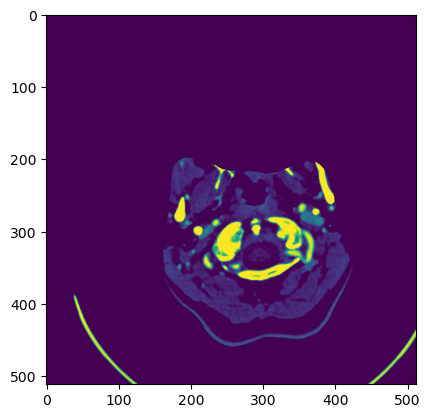

In [9]:
plt.imshow(volume[16])

# 5. Convert to .npy

In [10]:
series_path = [\
    f'../series/{series_id}' for series_id in os.listdir('../series') \
        if os.path.isdir(f'../series/{series_id}')
]

In [11]:
series_path[:10]

['../series/1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647',
 '../series/1.2.826.0.1.3680043.8.498.10004684224894397679901841656954650085',
 '../series/1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317',
 '../series/1.2.826.0.1.3680043.8.498.10009383108068795488741533244914370182',
 '../series/1.2.826.0.1.3680043.8.498.10012790035410518400400834395242853657',
 '../series/1.2.826.0.1.3680043.8.498.10014757658335054766479957992112625961',
 '../series/1.2.826.0.1.3680043.8.498.10021411248005513321236647460239137906',
 '../series/1.2.826.0.1.3680043.8.498.10022688097731894079510930966432818105',
 '../series/1.2.826.0.1.3680043.8.498.10022796280698534221758473208024838831',
 '../series/1.2.826.0.1.3680043.8.498.10023411164590664678534044036963716636']

In [12]:
# 解像度別の保存先ディレクトリの作成
save_dir = f'../series_npy/{CFG.size}'
os.makedirs(save_dir, exist_ok=True)

# series directoryのリストを作る
series_dir_paths = [\
    f'../series/{series_id}' for series_id in os.listdir('../series') \
        if os.path.isdir(f'../series/{series_id}')
]
print(f'Total series: {len(series_dir_paths)}')

# 途中から始める場合のseries_path
# if CFG.continued:
    
#     # すでに変換済みのSeriesInstanceUIDを取得
#     processed_series = os.listdir('../series_npy/512/')
#     # 念のため、最後に変換したSeriesInstanceUIDをリストから削除
#     processed_series.remove(CFG.start_series)
#     # 全てのSeriesInstanceUIDの中から、変換済みのものを除外
#     series_dir_paths = [path for path in series_path if Path(path).name not in processed_series]
#     print(f'Continuing from {CFG.start_series}, {len(series_path)}')

meta_df = pd.DataFrame()

for path in tqdm(series_dir_paths):
    
    series_id = Path(path).parent.name
    meta_dict = {
        'SeriesInstanceUID': series_id
    }
    
    # 各Seriesごとにディレクトリを作成
    save_path = f'{save_dir}/{Path(path).name}'
    os.makedirs(save_path, exist_ok=True)
    
    # volumeとmetadataの取得
    volume, metadata = process_dicom_series_safe(path)
    
    # metadataをmeta_dictに追加し、meta_dfに保存する
    meta_dict.update(metadata)
    meta_df = pd.concat([meta_df, pd.DataFrame(meta_dict, index=[0])], axis=0)
    
    # 一枚一枚保存する
    # for i in range(len(volume)):
        
    #     image = volume[i]
    #     image_index = str(i).zfill(5)
    #     npy_path = f"{save_path}/{image_index}.npy"
    #     np.save(npy_path, image)
        
    # print(f'npy files saved for series {Path(path).name} at {save_path}')

Total series: 4348


  0%|          | 0/4348 [00:00<?, ?it/s]

In [13]:
meta_df.to_csv('../meta_data/meta_data2.csv', index=False)

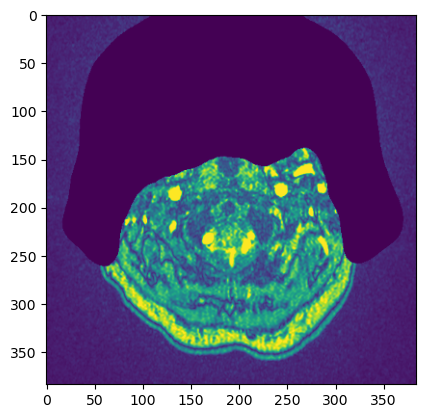

In [26]:
image = np.load('../series_npy/384/1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647/00000.npy')
plt.imshow(image)